In [63]:
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from rasterio.enums import Resampling
from PIL import ImageColor
#from skimage.exposure import rescale_intensity

# Preprocessing 

In [74]:
# Location of data
lc_json = 'C:/Users/farfar/deep-learning-lc-unet/data/lc.json'
#lc_image_dir = 'https://storage.googleapis.com/gee-ramiqcom-bucket/youtube/lc_python/LC_Image_v1.tif'
#palsar_dir = "https://storage.googleapis.com/gee-ramiqcom-bucket/youtube/lc_python/Palsar_Kerinci_2023_v1.tif"
#landsat_dir = "https://storage.googleapis.com/gee-ramiqcom-bucket/youtube/lc_python/Landsat_Kerinci_2023_v1.tif"

In [65]:
# Load Land Cover Parameter
lc = json.load(open(lc_json))
lc_df = pd.DataFrame(lc)
lc_df["values_normalize"] = lc_df.index + 1
lc_df["palette"] = "#" + lc_df["palette"]

# Mapping from old to new values
values = lc_df["values"].to_list()
values_norm = lc_df["values_normalize"].to_list()
palette = lc_df["palette"].to_list()
labels = lc_df["label"].to_list()
dict_values = {}
dict_label = {}
dict_palette = {}
dict_palette_hex = {}
for x in range(0, len(values)):
    dict_values[values[x]] = values_norm[x]
    dict_label[values_norm[x]] = labels[x]
    dict_palette[values_norm[x]] = ImageColor.getrgb(palette[x])
    dict_palette_hex[values_norm[x]] = palette[x]

# Create colormap from values and palette
cmap = ListedColormap(palette)

# Patches legend
patches = [
    mpatches.Patch(color=palette[i], label=labels[i]) for i in range(len(values))
]
legend = {
    "handles": patches,
    "bbox_to_anchor": (1.05, 1),
    "loc": 2,
    "borderaxespad": 0.0,
}

lc_df

,palette,values,label,values_normalize
0,#006400,2001,Primary dryland forest,1
1,#228B22,2002,Secondary dryland forest,2
2,#4B0082,2004,Primary mangrove forest,3
3,#808000,2005,Primary swamp forest,4
4,#32CD32,2006,Plantation forest,5
5,#90EE90,2007,Dry shrub,6
6,#FF4500,2010,Estate crop,7
7,#F08080,2012,Settlement,8
8,#D2B48C,2014,Bare ground,9
9,#ADFF2F,3000,Savanna and grasses,10


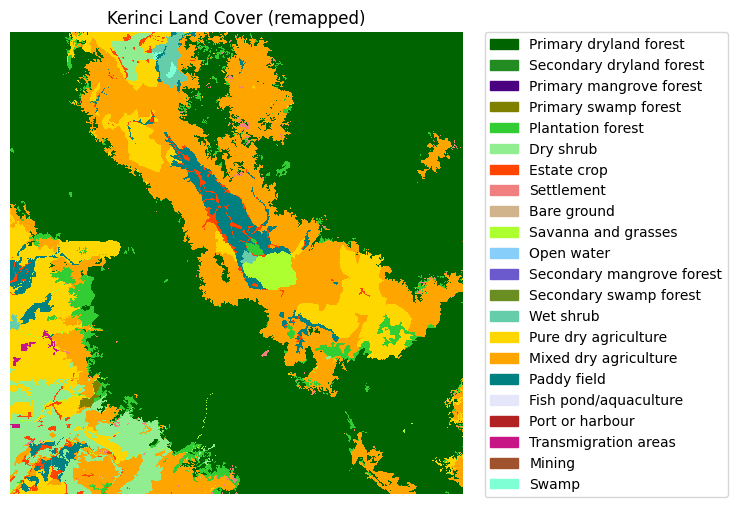

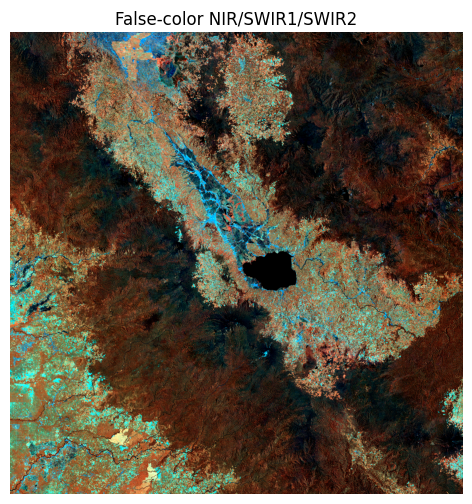

In [66]:
# --- imports ---
import os, json, math, random
import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.windows import Window
from rasterio.enums import Resampling
from PIL import ImageColor

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

import kornia as K
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# --- paths ---
lc_json = r"C:/Users/farfar/deep-learning-lc-unet/data/lc.json"
label_tif = "https://storage.googleapis.com/gee-ramiqcom-bucket/youtube/lc_python/LC_Image_v1.tif"
landsat_tif = "https://storage.googleapis.com/gee-ramiqcom-bucket/youtube/lc_python/Landsat_Kerinci_2023_v1.tif"

# --- read LC JSON, build mappings & colormap ---
lc = json.load(open(lc_json, "r"))
lc_df = pd.DataFrame(lc)
lc_df["values_normalize"] = lc_df.index 
lc_df["palette"] = "#" + lc_df["palette"]

values = lc_df["values"].tolist()
values_norm = lc_df["values_normalize"].tolist()
labels = lc_df["label"].tolist()
palette_hex = lc_df["palette"].tolist()

old2new = {old:new for old, new in zip(values, values_norm)}
id2label = {new:lab for new, lab in zip(values_norm, labels)}
id2color_hex = {new:hex for new, hex in zip(values_norm, palette_hex)}
id2color_rgb = {k:ImageColor.getrgb(v) for k,v in id2color_hex.items()}

cmap = ListedColormap(palette_hex)
legend_patches = [mpatches.Patch(color=palette_hex[i], label=labels[i]) for i in range(len(labels))]

# --- load label raster and remap to normalized ids (1..K) ---
with rio.open(label_tif) as src_lc:
    lc_img = src_lc.read(1)  # [H,W], original ids
    lc_profile = src_lc.profile

lc_norm = lc_img.copy()
for old, new in old2new.items():
    lc_norm[lc_img == old] = new

classes_present = np.unique(lc_norm)
num_classes = int(classes_present.max())  # assumes contiguous 1..K

# (optional) quick look
plt.figure(figsize=(6,6))
plt.imshow(lc_norm, cmap=cmap, interpolation='nearest', vmin=1, vmax=num_classes)
plt.axis("off")
plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("Kerinci Land Cover (remapped)")
plt.show()

# --- load Landsat stack and scale to reflectance ---
with rio.open(landsat_tif) as src_im:
    ms = src_im.read(out_dtype="float32") / 1e4  # [C,H,W] reflectance
    im_profile = src_im.profile
C, H, W = ms.shape

# --- Landsat-8/9 OLI center "wavelengths" in micrometers (µm) ---
#   B1: 0.443, B2: 0.482, B3: 0.562, B4: 0.655, B5: 0.865, B6: 1.61, B7: 2.20
# Adjust indices to your band order if your TIFF differs.
landsat_oli_um = [0.443, 0.482, 0.562, 0.655, 0.865, 1.61, 2.20, 0.59]
assert len(landsat_oli_um) == C, f"Expected {C} wavelengths, got {len(landsat_oli_um)}"

# --- small helper: percentile stretch for composites (no skimage) ---
def p_stretch(a, pmin=2, pmax=98):
    a = np.asarray(a, np.float32)
    lo, hi = np.percentile(a, [pmin, pmax])
    if hi <= lo: return np.zeros_like(a)
    return np.clip((a - lo) / (hi - lo), 0, 1).astype(np.float32)

# QC composite: NIR/SWIR1/SWIR2 (R,G,B)
nir, swir1, swir2 = ms[4], ms[5], ms[6]
comp = np.dstack([p_stretch(nir, 12.5, 99.5), p_stretch(swir1, 10, 99), p_stretch(swir2, 7.5, 99)])
plt.figure(figsize=(6,6)); plt.imshow(np.clip(comp,0,1)); plt.axis("off"); plt.title("False-color NIR/SWIR1/SWIR2"); plt.show()

In [72]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Bar chart of GT PIXELS per class (optional context) ----------
def plot_full_scene_pixel_distribution(
    lc_zero,
    num_classes,
    id2label,
    id2color_hex,
    title="GT pixel distribution per class",
    csv_path="full_scene_pixel_counts.csv",
    ignore_index=-1,
    present_only=False,
):
    # ------ DEBUG GUARDS ------
    if not np.issubdtype(lc_zero.dtype, np.integer):
        raise ValueError(f"lc_zero must be integer dtype, got {lc_zero.dtype}")
    vmin, vmax = int(lc_zero.min()), int(lc_zero.max())
    if vmin < ignore_index:
        print(f"[warn] lc_zero has values < {ignore_index}: min={vmin}. They will be ignored in counting.")
    if vmax >= num_classes:
        print(f"[warn] lc_zero has labels >= num_classes ({num_classes}): max={vmax}. "
              "Check your remapping is 0..K-1 after dropping classes.")

    # ------ COUNT NON-IGNORED PIXELS ------
    mask = lc_zero != ignore_index
    arr = lc_zero[mask]
    if arr.size == 0:
        raise ValueError("No valid pixels after masking ignore_index; cannot plot distribution.")
    # bincount now safe (all >=0)
    counts = np.bincount(arr, minlength=num_classes)[:num_classes]

    # Optionally keep only classes present in the scene
    if present_only:
        present_idx = np.where(counts > 0)[0]
        classes = present_idx.tolist()
        counts = counts[present_idx]
    else:
        classes = list(range(num_classes))

    names  = [id2label[i] for i in classes]
    colors = [id2color_hex.get(i, "#888888") for i in classes]
    total  = max(1, counts.sum())
    perc   = counts / total * 100.0

    # ------ SAVE TABLE ------
    df = pd.DataFrame({
        "class_id": classes,
        "class_name": names,
        "pixel_count": counts,
        "percent": perc
    })
    df.to_csv(csv_path, index=False)
    print(df.round(2))

    # ------ PLOT ------
    fig_w = max(10, min(30, 0.5*len(classes)+6))
    plt.figure(figsize=(fig_w, 6))
    x = np.arange(len(classes))
    bars = plt.bar(x, counts, color=colors, edgecolor="black")

    for i, b in enumerate(bars):
        y = b.get_height()
        plt.text(b.get_x()+b.get_width()/2, y, f"{int(counts[i]):,}\n({perc[i]:.1f}%)",
                 ha="center", va="bottom", fontsize=9)

    plt.xticks(x, [f"{c}: {names[i]}" for i, c in enumerate(classes)], rotation=45, ha="right")
    plt.ylabel("Pixel count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    class_id                 class_name  pixel_count  percent
0          0     Primary dryland forest      4122671    55.67
1          1   Secondary dryland forest       281245     3.80
2          2    Primary mangrove forest         7046     0.10
3          3       Primary swamp forest       192387     2.60
4          4          Plantation forest       303599     4.10
5          5                  Dry shrub        66624     0.90
6          6                Estate crop        19800     0.27
7          7                 Settlement        61426     0.83
8          8                Bare ground        41048     0.55
9          9        Savanna and grasses       681114     9.20
10        10                 Open water      1402973    18.94
11        11  Secondary mangrove forest       213684     2.89
12        12     Secondary swamp forest         7880     0.11
13        13                  Wet shrub         4155     0.06
14        14       Pure dry agriculture            0     0.00
15      

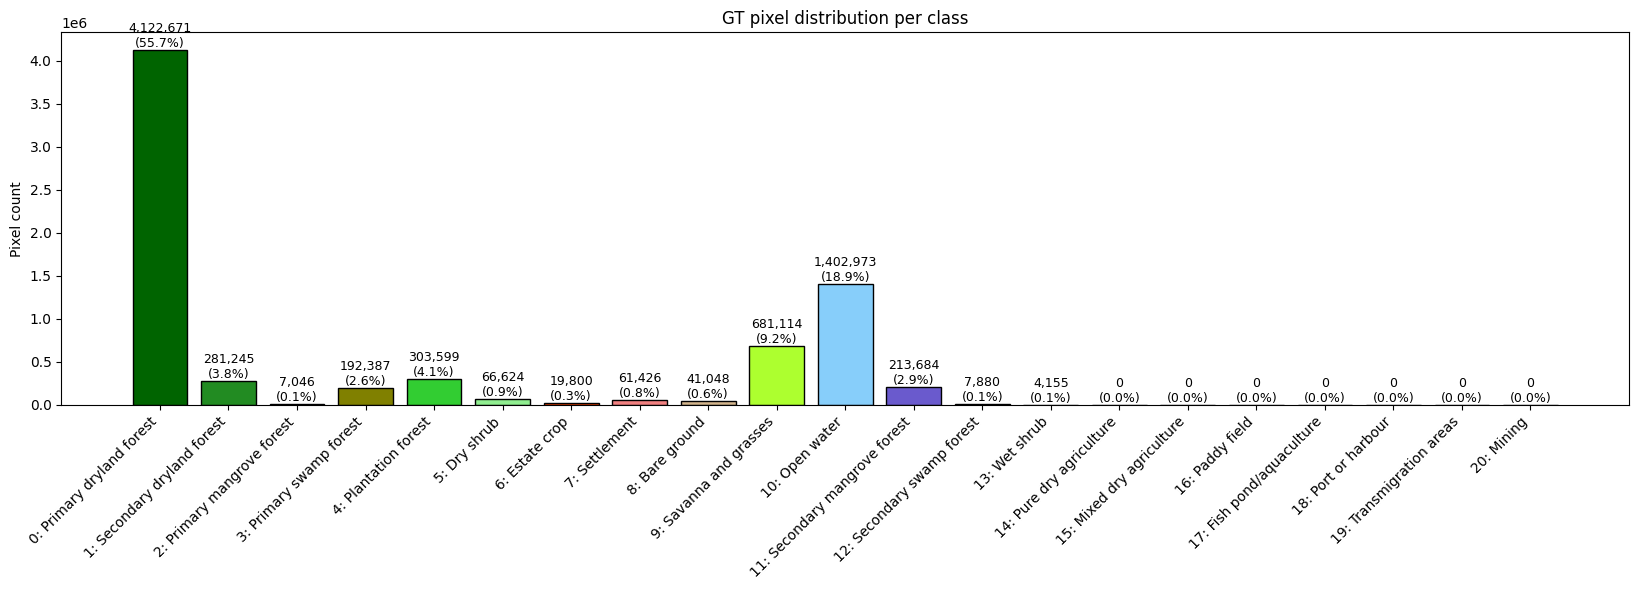

In [73]:
# full-scene pixels (now ignores -1 safely)
plot_full_scene_pixel_distribution(lc_zero, num_classes, id2label, id2color_hex,
                                   present_only=False,  # or True to hide zeros
                                   ignore_index=-1)

# Modelling

In [78]:
# ======================= SETUP & IMPORTS =======================
import os, json, math, time, sys, random
import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.enums import Resampling
from PIL import ImageColor

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# DOFA from torchgeo
from torchgeo.models import dofa_base_patch16_224, DOFABase16_Weights

import matplotlib.pyplot as plt

# ----------------------- PATHS -----------------------
#lc_json      = r"C:/Users/farfar/deep-learning-lc-unet/data/lc.json"
#landsat_tif  = "https://storage.googleapis.com/gee-ramiqcom-bucket/youtube/lc_python/Landsat_Kerinci_2023_v1.tif"
#label_tif    = "https://storage.googleapis.com/gee-ramiqcom-bucket/youtube/lc_python/LC_Image_v1.tif"

# ----------------------- DEVICE -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ======================= 1) READ LABEL JSON (FILTER + REMAP) =======================
# Classes to REMOVE entirely (absent in ROI)
DROP_LABELS = {
    "Primary mangrove forest",
    "Primary swamp forest",
    "Savanna and grasses",
    "Secondary mangrove forest",
    "Secondary swamp forest",
    "Fish pond/aquaculture",
    "Port or harbour",
    "Mining",
}

lc = json.load(open(lc_json, "r"))
lc_df_full = pd.DataFrame(lc)
lc_df_full["values_normalize"] = lc_df_full.index
lc_df_full["palette"] = "#" + lc_df_full["palette"]

# Keep only classes not in DROP_LABELS
keep_mask = ~lc_df_full["label"].isin(DROP_LABELS)
lc_df = lc_df_full[keep_mask].reset_index(drop=True)

# New contiguous IDs 0..K'-1
lc_df["new_id"] = lc_df.index

# Mappings (original code -> new contiguous id)
old_values = lc_df["values"].tolist()      # original GEE codes for KEPT classes
new_ids    = lc_df["new_id"].tolist()      # 0..K'-1
labels     = lc_df["label"].tolist()
palette_hex= lc_df["palette"].tolist()

old2new_keep   = {o:n for o,n in zip(old_values, new_ids)}   # for kept classes
dropped_values = set(lc_df_full.loc[~keep_mask, "values"].tolist())  # for info only

# Pretty maps for plotting / reports
id2label      = {n:l for n,l in zip(new_ids, labels)}
id2color_hex  = {n:h for n,h in zip(new_ids, palette_hex)}
id2color_rgb  = {k: ImageColor.getrgb(v) for k,v in id2color_hex.items()}
num_classes   = len(new_ids)

print("Kept classes:", num_classes, "->", [id2label[i] for i in range(num_classes)])

# ======================= 2) READ RASTERS =======================
# Land cover -> map kept classes to 0..K'-1, drop others to -1 (ignored)
with rio.open(label_tif) as src_lc:
    lc_img = src_lc.read(1)
H, W = lc_img.shape

lc_zero = np.full((H, W), -1, dtype=np.int32)  # -1 for dropped/absent
for o, n in old2new_keep.items():
    lc_zero[lc_img == o] = n  # map only KEPT class codes

# Landsat stack -> reflectance
with rio.open(landsat_tif) as src_im:
    ms = src_im.read(out_dtype="float32") / 1e-4 / 1e+0  # keep your original reflectance scaling (0–1)
    # If your data are already 0–1, replace the line above with:  ms = src_im.read(out_dtype="float32")
    profile = src_im.profile
C = ms.shape[0]
print("ms shape:", ms.shape, "lc shape:", lc_zero.shape)

# Wavelengths (µm) matching band order in your TIFF (adjust if needed!)
landsat_oli_um = [0.443, 0.482, 0.562, 0.655, 0.865, 1.61, 2.20, 0.59]
assert len(landsat_oli_um) == C, "Mismatch between channels and wavelengths!"
wvs = landsat_oli_um  # used later

# ======================= 3) PATCH LIST PER CLASS (YOUR STYLE, WITH FIXES) =======================
# Width/height of the new image
image_width = 128
r = image_width // 2

# Desired per-class patches
image_per_lc = 400

# Optional: jitter centers by a few pixels to diversify duplicates
center_jitter = 8   # set 0 to disable

# Discover kept class IDs actually present (>=0)
present_ids = sorted([int(i) for i in np.unique(lc_zero) if i >= 0])
plt.figure(figsize=(4 * image_per_lc, 4 * max(1, len(present_ids))))  # keep your figure call

coords_dict = {}   # {class_id: [[min_y,max_y,min_x,max_x], ...]}
items_all  = []    # [(y_center, x_center, class_id), ...]

# Get the land cover clip using the width
for x in range(0, len(present_ids)):
    # Get land cover class value (new contiguous id)
    lc_id = int(present_ids[x])

    # Get list of image pixel coordinate with this class value
    coords = np.argwhere(lc_zero == lc_id)
    coords_filter = []

    # Filter only centers far enough from borders to fit a full patch
    for c in coords:
        cond1 = (c[0] - r) >= 0
        cond2 = (c[1] - r) >= 0
        cond3 = (c[0] + r) <= H
        cond4 = (c[1] + r) <= W
        if cond1 and cond2 and cond3 and cond4:
            coords_filter.append(c)

    coords_dict[lc_id] = []

    # If the filtered coordinates exist then generate pixel bounds
    if len(coords_filter) > 0:
        n_valid = len(coords_filter)

        # sample indices (with replacement only if we need more than available)
        seq = np.arange(n_valid)                                   # BUGFIX: no "-1"
        replace = image_per_lc > n_valid
        sample_idx = np.random.choice(seq, size=image_per_lc, replace=replace)
        sample_coord = [coords_filter[i] for i in sample_idx]

        # Generate the pixel bounds
        for y in range(0, len(sample_coord)):
            # Center coordinate
            cy, cx = int(sample_coord[y][0]), int(sample_coord[y][1])

            # Optional random jitter for diversity
            if center_jitter > 0:
                cy += int(np.random.randint(-center_jitter, center_jitter + 1))
                cx += int(np.random.randint(-center_jitter, center_jitter + 1))
                cy = int(np.clip(cy, r, H - r - 1))
                cx = int(np.clip(cx, r, W - r - 1))

            # Min/max of the coordinate
            max_y = int(cy + r)
            min_y = int(cy - r)
            max_x = int(cx + r)
            min_x = int(cx - r)

            # Add to the coordinate list
            coords_dict[lc_id].append([min_y, max_y, min_x, max_x])

            # Keep center list too (useful for dataset/splits)
            items_all.append((cy, cx, lc_id))

print("Total patches (all classes):", len(items_all))

# ======================= 4) STRATIFIED SPLIT =======================
rng = np.random.default_rng(123)
rng.shuffle(items_all)

FRAC = dict(train=0.70, val=0.15, test=0.15)
n = len(items_all)
i1 = int(round(FRAC["train"]*n))
i2 = i1 + int(round(FRAC["val"]*n))
items_train, items_val, items_test = items_all[:i1], items_all[i1:i2], items_all[i2:]

print("items:", len(items_train), len(items_val), len(items_test))

# ======================= 5) BAND STATS (from train subset) =======================
def estimate_mean_std(ms, items, sample_k=1500, patch=image_width):
    if len(items) == 0:
        raise ValueError("No items to estimate mean/std from.")
    k = min(sample_k, len(items))
    idxs = rng.choice(len(items), size=k, replace=False)
    acc_sum = np.zeros(ms.shape[0], np.float64)
    acc_sq  = np.zeros(ms.shape[0], np.float64)
    r_ = patch//2
    for i in idxs:
        y,x,_ = items[i]
        tile = ms[:, y-r_:y+r_, x-r_:x+r_].reshape(ms.shape[0], -1)
        acc_sum += tile.mean(axis=1)
        acc_sq  += (tile**2).mean(axis=1)
    mean = (acc_sum / max(1,k)).astype(np.float32)
    var  = (acc_sq / max(1,k)) - (mean**2)
    std  = np.sqrt(np.clip(var, 1e-8, None)).astype(np.float32)
    return mean, std

band_mean, band_std = estimate_mean_std(ms, items_train, sample_k=2000, patch=image_width)
print("band_mean:", np.round(band_mean,4))
print("band_std :", np.round(band_std ,4))

# ======================= 6) DATASET/LOADER (PyTorch only; mask-safe augs) =======================
IGNORE_IDX = -1  # IMPORTANT: we set dropped classes to -1 and ignore them in the loss/metrics

class KerinciDS(Dataset):
    def __init__(self, ms_arr, lc_arr, items, mean, std, patch=image_width, augment=True):
        self.ms = ms_arr
        self.lc = lc_arr
        self.items = items
        self.P = patch
        self.r = patch//2
        self.C = ms_arr.shape[0]
        self.augment = augment
        self.mean = torch.as_tensor(mean).view(-1,1,1)
        self.std  = torch.as_tensor(std ).view(-1,1,1)

    def __len__(self): return len(self.items)

    def _normalize(self, img): return (img - self.mean) / (self.std + 1e-6)

    def _augment(self, img, msk):
        # flips
        if random.random() < 0.5:
            img = torch.flip(img, [2]); msk = torch.flip(msk, [1])
        if random.random() < 0.5:
            img = torch.flip(img, [1]); msk = torch.flip(msk, [0])
        # 0/90/180/270 rotate
        if random.random() < 0.5:
            k = random.randint(0,3)
            if k: img = torch.rot90(img, k, [1,2]); msk = torch.rot90(msk, k, [0,1])
        return img, msk

    def __getitem__(self, idx):
        y,x,cid = self.items[idx]
        y0,y1 = y-self.r, y+self.r
        x0,x1 = x-self.r, x+self.r
        img = self.ms[:, y0:y1, x0:x1].copy()
        msk = self.lc[y0:y1, x0:x1].copy().astype(np.int64)  # contains 0..K'-1 and -1 (ignored)

        img = torch.from_numpy(img).float()
        msk = torch.from_numpy(msk).long()

        img = self._normalize(img)
        if self.augment: img, msk = self._augment(img, msk)
        return {"image": img, "mask": msk}

train_ds = KerinciDS(ms, lc_zero, items_train, band_mean, band_std, augment=True)
val_ds   = KerinciDS(ms, lc_zero, items_val,   band_mean, band_std, augment=False)
test_ds  = KerinciDS(ms, lc_zero, items_test,  band_mean, band_std, augment=False)

# Windows/Jupyter safe
NW = 0
BS = 16
train_dl = DataLoader(train_ds, batch_size=BS, shuffle=True,  num_workers=NW, drop_last=False)
val_dl   = DataLoader(val_ds,   batch_size=BS, shuffle=False, num_workers=NW)
test_dl  = DataLoader(test_ds,  batch_size=BS, shuffle=False, num_workers=NW)

print("Train/Val/Test steps:", len(train_dl), len(val_dl), len(test_dl))

# ======================= 7) DOFA ENCODER + SIMPLE DECODER =======================
dofa = dofa_base_patch16_224(weights=DOFABase16_Weights.DOFA_MAE)

class DOFASegWrapper(nn.Module):
    def __init__(self, enc):
        super().__init__()
        self.encoder = enc

    @staticmethod
    def _interp_pos_embed(pos_embed, new_hw):
        """
        pos_embed: [1, 1+N0, D]  (cls + patch positions for the pretrain grid, e.g., 14x14)
        new_hw: (H', W') token grid (e.g., (8,8) for 128x128 with patch16)
        returns: [1, 1+N', D] interpolated positional embeddings
        """
        cls_pe = pos_embed[:, :1, :]             # [1,1,D]
        patch_pe = pos_embed[:, 1:, :]           # [1,N0,D]
        N0, D = patch_pe.shape[1], patch_pe.shape[2]
        S0 = int(math.sqrt(N0))
        assert S0 * S0 == N0, "pos_embed patch tokens must form a square grid"

        # [1,D,S0,S0] -> interpolate -> [1,D,H',W'] -> [1,H'*W',D]
        patch_pe = patch_pe.reshape(1, S0, S0, D).permute(0, 3, 1, 2)   # [1,D,S0,S0]
        patch_pe = F.interpolate(patch_pe, size=new_hw, mode="bicubic", align_corners=False)
        patch_pe = patch_pe.permute(0, 2, 3, 1).reshape(1, new_hw[0]*new_hw[1], D)
        return torch.cat([cls_pe, patch_pe], dim=1)                     # [1,1+N',D]

    def forward(self, x, wavelengths):
        waves = torch.as_tensor(wavelengths, device=x.device, dtype=torch.float32)

        # patchify with spectral embedding
        tokens, _ = self.encoder.patch_embed(x, waves)  # [B,N,D]
        B, N, D = tokens.shape
        S = int(math.sqrt(N))
        assert S * S == N, "Token sequence is not square; check input size / patch size"

        # interpolate positional embeddings to (S,S)
        pos = self._interp_pos_embed(self.encoder.pos_embed, (S, S))    # [1,1+N,D]

        # add positional encodings
        tokens = tokens + pos[:, 1:, :]                                 # [B,N,D]
        cls = (self.encoder.cls_token + pos[:, :1, :]).expand(B, -1, -1)# [B,1,D]
        tokens = torch.cat((cls, tokens), dim=1)                        # [B,1+N,D]

        # transformer blocks
        for blk in self.encoder.blocks:
            tokens = blk(tokens)

        # drop cls, reshape to feature map
        toks = tokens[:, 1:]                                            # [B,N,D]
        return toks.reshape(B, S, S, D).permute(0, 3, 1, 2).contiguous() # [B,768,S,S]

encoder = DOFASegWrapper(dofa).to(device)
for p in encoder.parameters(): p.requires_grad = False

class SimpleFCNDecoder(nn.Module):
    def __init__(self, in_ch=768, num_classes=num_classes, out_size=(image_width,image_width)):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, in_ch//2, 3, padding=1), nn.BatchNorm2d(in_ch//2), nn.ReLU(True),
            nn.Conv2d(in_ch//2, in_ch//4, 3, padding=1), nn.BatchNorm2d(in_ch//4), nn.ReLU(True),
            nn.Conv2d(in_ch//4, num_classes, 1)
        )
        self.out_size = out_size
    def forward(self, x):
        x = self.net(x)
        return F.interpolate(x, size=self.out_size, mode="bilinear", align_corners=False)

decoder = SimpleFCNDecoder().to(device)

criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_IDX)  # ignore dropped-class pixels
optim = torch.optim.AdamW(decoder.parameters(), lr=1e-4, weight_decay=1e-4)

# ======================= 8) TRAINING (Keras-style live bar) =======================
BAR_LEN = 30
def _pixel_acc(logits, y, ignore_index=IGNORE_IDX):
    pred = logits.argmax(1)
    if ignore_index is not None:
        mask = (y != ignore_index)
        num = (pred[mask] == y[mask]).sum().item()
        den = mask.sum().item()
    else:
        num = (pred == y).sum().item()
        den = y.numel()
    return num, max(1, den)

def _fmt_time(sec):
    sec = int(sec); m, s = divmod(sec, 60); h, m = divmod(m, 60)
    return (f"{s}s" if sec<60 else f"{m}m {s}s" if h==0 else f"{h}h {m}m {s}s")

def _progress_line(step, total, elapsed, loss_avg, acc_avg, prefix=""):
    filled = int(BAR_LEN * step / max(1,total))
    bar = "="*filled + "."*(BAR_LEN - filled)
    ms_per_step = 1000.0 * elapsed / max(1, step)
    return (f"{prefix}{step}/{total} [{bar}] - "
            f"{_fmt_time(elapsed)} {ms_per_step:.0f}ms/step - "
            f"loss: {loss_avg:.4f} - categorical_accuracy: {acc_avg:.4f}")

@torch.no_grad()
def forward_feats(x): return encoder(x, wvs)

def run_epoch(loader, train=True):
    decoder.train(train)
    total_loss = 0.0; correct = 0; denom = 0
    total_steps = len(loader); start = time.time()
    sys.stdout.write(_progress_line(0, total_steps, 0, 0.0, 0.0, "Train " if train else "Val   ")+"\r"); sys.stdout.flush()
    for i, b in enumerate(loader, 1):
        x = b["image"].to(device); y = b["mask"].to(device)
        with torch.no_grad(): f = forward_feats(x)
        logits = decoder(f)
        loss = criterion(logits, y)
        if train:
            optim.zero_grad(); loss.backward(); optim.step()
        total_loss += float(loss.item())
        c, d = _pixel_acc(logits, y, ignore_index=IGNORE_IDX); correct += c; denom += d
        if torch.cuda.is_available(): torch.cuda.synchronize()
        elapsed = time.time()-start
        sys.stdout.write("\r"+_progress_line(i,total_steps,elapsed,total_loss/i,correct/max(1,denom),"Train " if train else "Val   "))
        sys.stdout.flush()
    sys.stdout.write("\n"); sys.stdout.flush()
    return total_loss/max(1,len(loader)), correct/max(1,denom)

EPOCHS = 400
train_acc_hist, train_loss_hist = [], []
val_acc_hist,   val_loss_hist   = [], []
print(f"Train steps: {len(train_dl)} | Val steps: {len(val_dl)}")
for ep in range(1, EPOCHS+1):
    print(f"Epoch {ep}/{EPOCHS}")
    tr_loss, tr_acc = run_epoch(train_dl, True)
    va_loss, va_acc = run_epoch(val_dl,   False)

    # Record 
    train_loss_hist.append(tr_loss)
    train_acc_hist.append(tr_acc)
    val_loss_hist.append(va_loss)
    val_acc_hist.append(va_acc)
    steps = len(train_dl)
    print(f"{steps}/{steps} [==============================] - "
          f"loss: {tr_loss:.4f} - categorical_accuracy: {tr_acc:.4f} - "
          f"val_loss: {va_loss:.4f} - val_categorical_accuracy: {va_acc:.4f}")

device: cuda
Kept classes: 14 -> ['Primary dryland forest', 'Secondary dryland forest', 'Plantation forest', 'Dry shrub', 'Estate crop', 'Settlement', 'Bare ground', 'Open water', 'Wet shrub', 'Pure dry agriculture', 'Mixed dry agriculture', 'Paddy field', 'Transmigration areas', 'Swamp']
ms shape: (8, 2751, 2692) lc shape: (2751, 2692)
Total patches (all classes): 5600
items: 3920 840 840
band_mean: [ 2122242.    2539858.    5021213.5   3627962.2  30388440.   15165170.
  6810708.     223981.77]
band_std : [1486167.4 1527654.  1849773.9 2162177.2 9062764.  4947116.5 3056864.
 1126705.5]
Train/Val/Test steps: 245 53 53
Train steps: 245 | Val steps: 53
Epoch 1/400
Train 245/245 [==============================] - 13s 57ms/step - loss: 1.2494 - categorical_accuracy: 0.6130
Val   53/53 [==============================] - 2s 43ms/step - loss: 0.9617 - categorical_accuracy: 0.6846
245/245 [==============================] - loss: 1.2494 - categorical_accuracy: 0.6130 - val_loss: 0.9617 - val_ca

<Figure size 160000x5600 with 0 Axes>

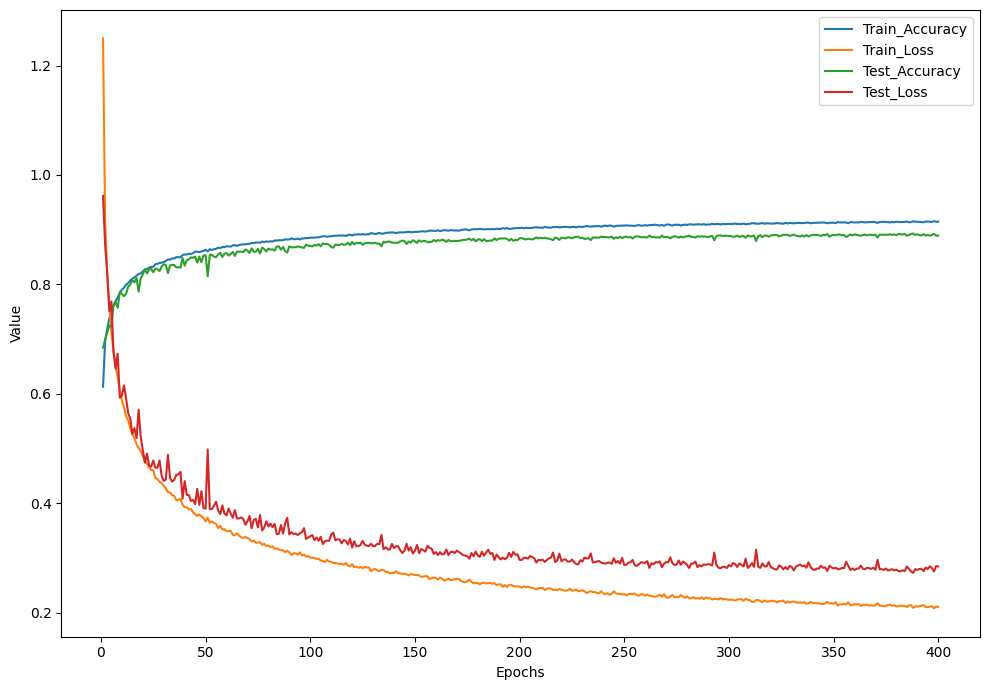

In [79]:
# ---- plot (same style as your example) ----
import numpy as np, matplotlib.pyplot as plt
n = min(len(train_acc_hist), len(train_loss_hist), len(val_acc_hist), len(val_loss_hist))
epochs = np.arange(1, n + 1)

plt.figure(figsize=(10,7))
plt.plot(epochs, train_acc_hist[:n], label="Train_Accuracy")
plt.plot(epochs, train_loss_hist[:n], label="Train_Loss")
plt.plot(epochs, val_acc_hist[:n],   label="Test_Accuracy")
plt.plot(epochs, val_loss_hist[:n],  label="Test_Loss")
plt.xlabel("Epochs"); plt.ylabel("Value"); plt.legend(loc="upper right"); plt.tight_layout()
plt.show()

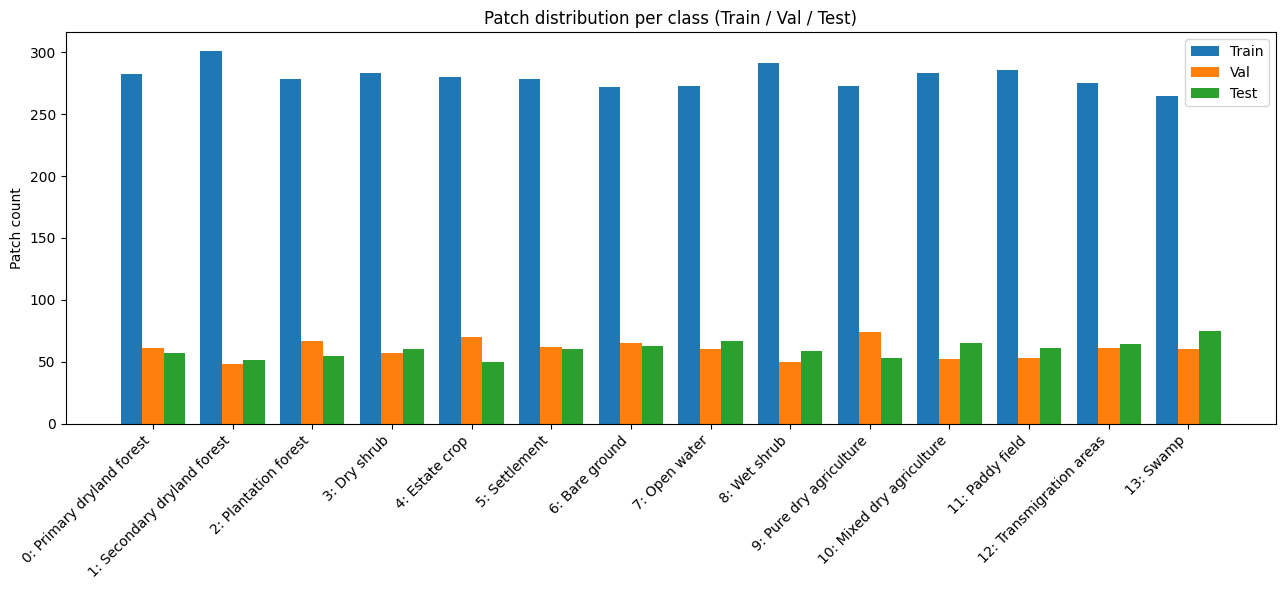

In [80]:
# ==============================
# 2) BAR CHART: PATCH COUNTS PER CLASS (TRAIN / VAL / TEST)
# ==============================
from collections import Counter

def counts_from_items(items, K):
    c = Counter(cid for _,_,cid in items)
    return np.array([c.get(i, 0) for i in range(K)], dtype=int)

train_counts = counts_from_items(items_train, num_classes)
val_counts   = counts_from_items(items_val,   num_classes)
test_counts  = counts_from_items(items_test,  num_classes)

classes = list(range(num_classes))
names   = [id2label[i] for i in classes]

# Grouped bar chart
x = np.arange(len(classes))
w = 0.27
fig_w = max(10, min(30, 0.5*len(classes)+6))
plt.figure(figsize=(fig_w, 6))
plt.bar(x - w, train_counts, width=w, label="Train")
plt.bar(x,       val_counts, width=w, label="Val")
plt.bar(x + w,   test_counts, width=w, label="Test")
plt.xticks(x, [f"{i}: {names[i]}" for i in classes], rotation=45, ha="right")
plt.ylabel("Patch count")
plt.title("Patch distribution per class (Train / Val / Test)")
plt.legend()
plt.tight_layout()
plt.show()

In [81]:
# ======================= 9) EVALUATION: CONFUSION MATRIX & REPORT =======================
@torch.no_grad()
def confusion_matrix_seg(dloader, K):
    decoder.eval(); encoder.eval()
    cm = torch.zeros(K, K, dtype=torch.long, device=device)
    for b in dloader:
        x = b["image"].to(device); y = b["mask"].to(device)  # y in 0..K-1
        f = forward_feats(x); pred = decoder(f).argmax(1)
        idx = y*K + pred
        hist = torch.bincount(idx.view(-1), minlength=K*K).reshape(K,K)
        cm += hist
    return cm.cpu().numpy()

def per_class_from_cm(cm):
    tp = np.diag(cm).astype(float)
    fp = cm.sum(0) - tp; fn = cm.sum(1) - tp
    eps = 1e-9
    precision = tp / np.maximum(tp+fp, eps)
    recall    = tp / np.maximum(tp+fn, eps)
    f1        = 2*precision*recall / np.maximum(precision+recall, eps)
    iou       = tp / np.maximum(tp+fp+fn, eps)
    OA   = tp.sum() / np.maximum(cm.sum(), eps)
    mIoU = np.mean(iou); macroF1 = np.mean(f1)
    return precision, recall, f1, iou, OA, mIoU, macroF1

cm = confusion_matrix_seg(test_dl, num_classes)
prec, rec, f1, iou, OA, mIoU, macroF1 = per_class_from_cm(cm)
report = pd.DataFrame({
    #"class_id": list(range(num_classes)),
    "class_name": [id2label[i] for i in range(num_classes)],
    "support": cm.sum(axis=1).astype(int),
    "precision": prec, "recall": rec, "f1": f1, "IoU": iou
})
print(report.round(4))
print(f"\nOverall -> OA: {OA:.4f} | mIoU: {mIoU:.4f} | macroF1: {macroF1:.4f}")
report.to_csv("per_class_report.csv", index=False)
pd.DataFrame(cm, index=report["class_name"], columns=report["class_name"]).to_csv("confusion_matrix_raw.csv")

# ======================= 10) (OPTIONAL) FULL-SCENE INFERENCE (tile) =======================
def normalize_stack(ms_arr, mean, std):
    return (ms_arr - mean[:,None,None]) / (std[:,None,None] + 1e-6)

@torch.no_grad()
def predict_full_scene(ms_arr, tile=512, stride=448, mean=None, std=None):
    C,H,W = ms_arr.shape
    pred = np.zeros((H,W), np.int64)
    vote = np.zeros((H,W), np.int32)

    mean = band_mean if mean is None else mean
    std  = band_std  if std  is None else std

    r = tile
    for y0 in range(0, H, stride):
        for x0 in range(0, W, stride):
            y1 = min(y0+r, H); x1 = min(x0+r, W)
            patch = np.zeros((C,r,r), np.float32)
            patch[:, :y1-y0, :x1-x0] = ms_arr[:, y0:y1, x0:x1]
            patch = normalize_stack(patch, mean, std)
            x = torch.from_numpy(patch).unsqueeze(0).to(device)
            f = forward_feats(x)
            p = decoder(f).argmax(1)[0].cpu().numpy()
            pred[y0:y1, x0:x1] += p[:y1-y0, :x1-x0]
            vote[y0:y1, x0:x1] += 1

    vote[vote==0] = 1
    return (pred // vote).astype(np.int64)

# Example call (comment out if not needed)
#full_pred = predict_full_scene(ms, tile=512, stride=448)
#print("full_pred range:", full_pred.min(), full_pred.max())

                  class_name  support  precision  recall      f1     IoU
0     Primary dryland forest  1788586     0.9395  0.9416  0.9405  0.8878
1   Secondary dryland forest   715567     0.7708  0.7404  0.7553  0.6068
2          Plantation forest   221341     0.9356  0.9455  0.9405  0.8877
3                  Dry shrub   697066     0.7696  0.7884  0.7789  0.6378
4                Estate crop  1148883     0.8857  0.9089  0.8971  0.8135
5                 Settlement   337494     0.7667  0.6702  0.7152  0.5567
6                Bare ground    93057     0.6311  0.4095  0.4967  0.3304
7                 Open water   789279     0.9572  0.9238  0.9402  0.8871
8                  Wet shrub  1230138     0.9672  0.9570  0.9621  0.9269
9       Pure dry agriculture  2226442     0.9007  0.9302  0.9152  0.8436
10     Mixed dry agriculture  2980697     0.8928  0.8890  0.8909  0.8032
11               Paddy field  1135940     0.8804  0.9030  0.8915  0.8043
12      Transmigration areas   153104     0.8092  0

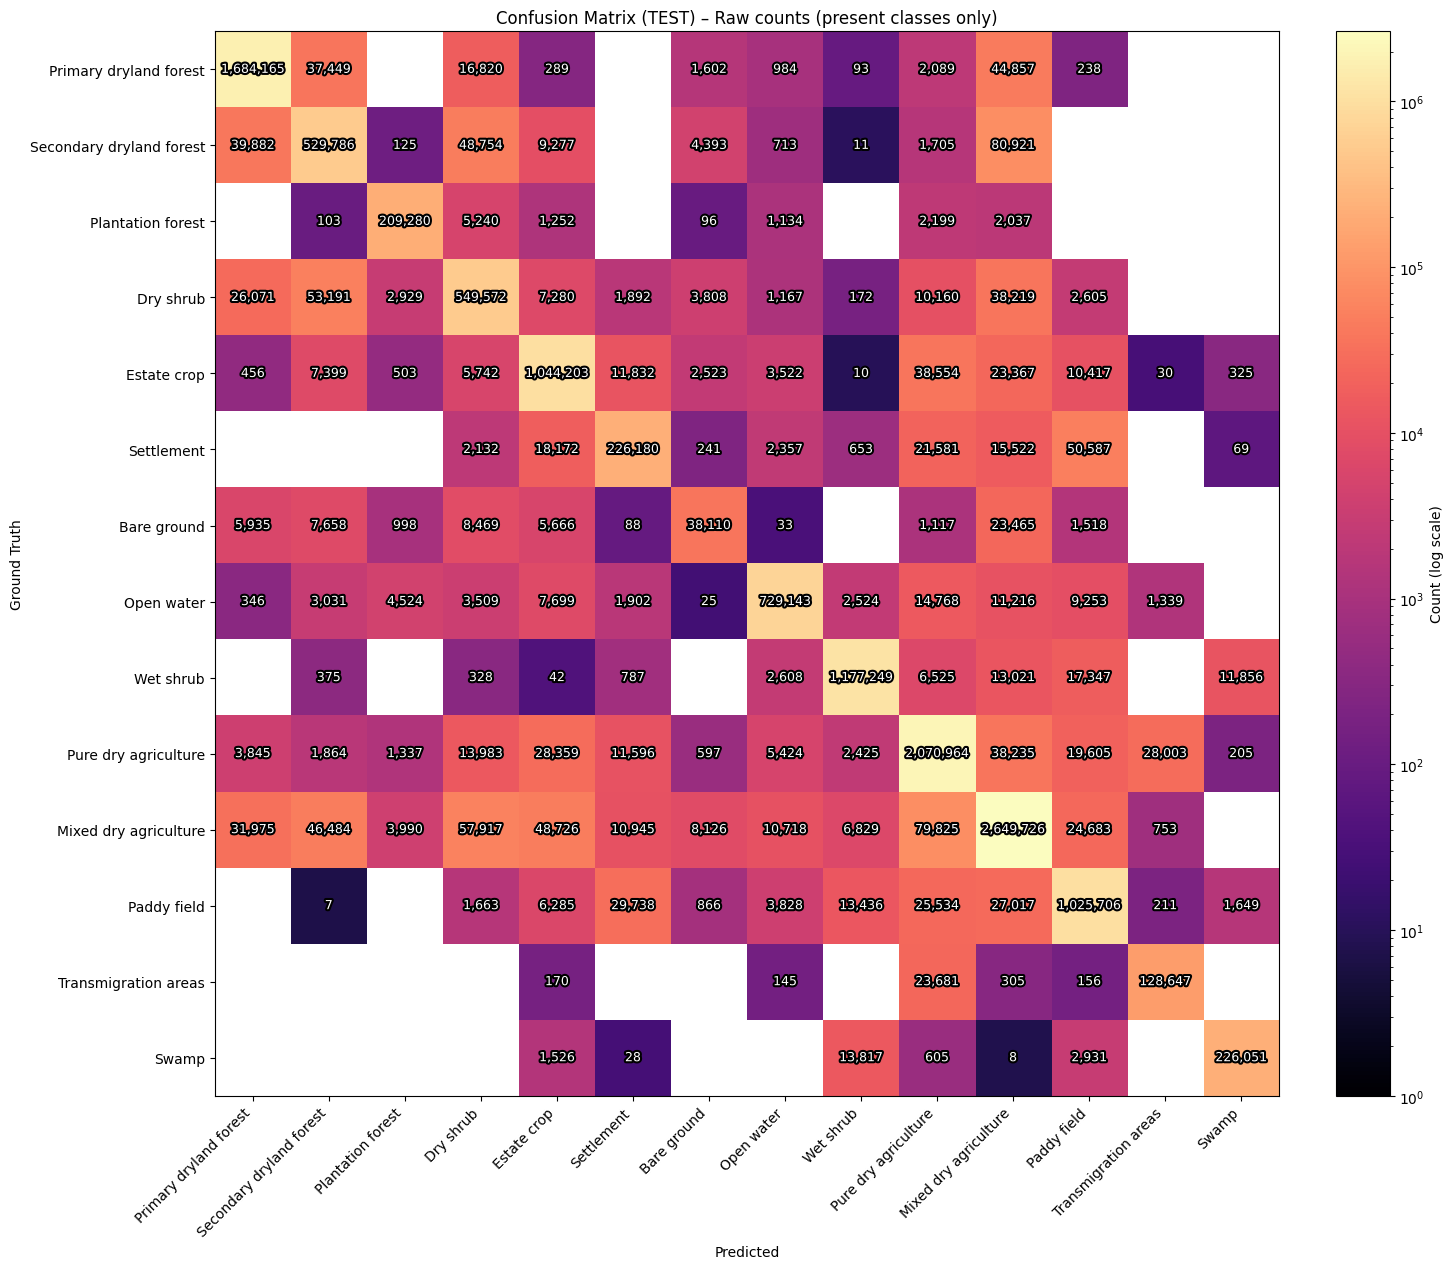

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patheffects as pe

def plot_cm_counts_present(cm, id2label, title="Confusion Matrix (TEST) – Raw counts (present classes only)"):
    """
    cm: ndarray [K,K], rows=GT, cols=Pred (built from your test dataloader)
    id2label: dict {class_id -> class_name}
    """
    # keep only classes that actually appear in TEST GT
    support = cm.sum(axis=1)
    present_idx = np.where(support > 0)[0]
    cm_p = cm[present_idx][:, present_idx]
    names = [id2label[i] for i in present_idx]
    K = len(present_idx)

    # mask zeros so they render with background color, and use log scale for dynamic range
    cm_masked = np.ma.masked_where(cm_p == 0, cm_p)
    vmax = int(cm_p.max()) if cm_p.size else 1

    fig_w = max(10, 0.7 * K + 6)
    fig_h = max(6,  0.7 * K + 3)
    plt.figure(figsize=(fig_w, fig_h))

    im = plt.imshow(cm_masked, cmap="magma", norm=LogNorm(vmin=1, vmax=max(1, vmax)))
    plt.colorbar(im, fraction=0.046, pad=0.04, label="Count (log scale)")

    plt.xticks(range(K), names, rotation=45, ha="right")
    plt.yticks(range(K), names)
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.title(title)

    # annotate counts in WHITE (with black outline for readability)
    text_effect = [pe.withStroke(linewidth=3, foreground="black")]
    fs = 8 if K > 16 else 9 if K > 12 else 10

    for i in range(K):
        for j in range(K):
            c = int(cm_p[i, j])
            if c == 0:
                continue
            plt.text(j, i, f"{c:,}", ha="center", va="center",
                     color="white", fontsize=fs, path_effects=text_effect)

    plt.tight_layout()
    plt.show()

# --- use it ---
# cm = confusion_matrix_seg(test_dl, num_classes)  # your existing function
plot_cm_counts_present(cm, id2label)

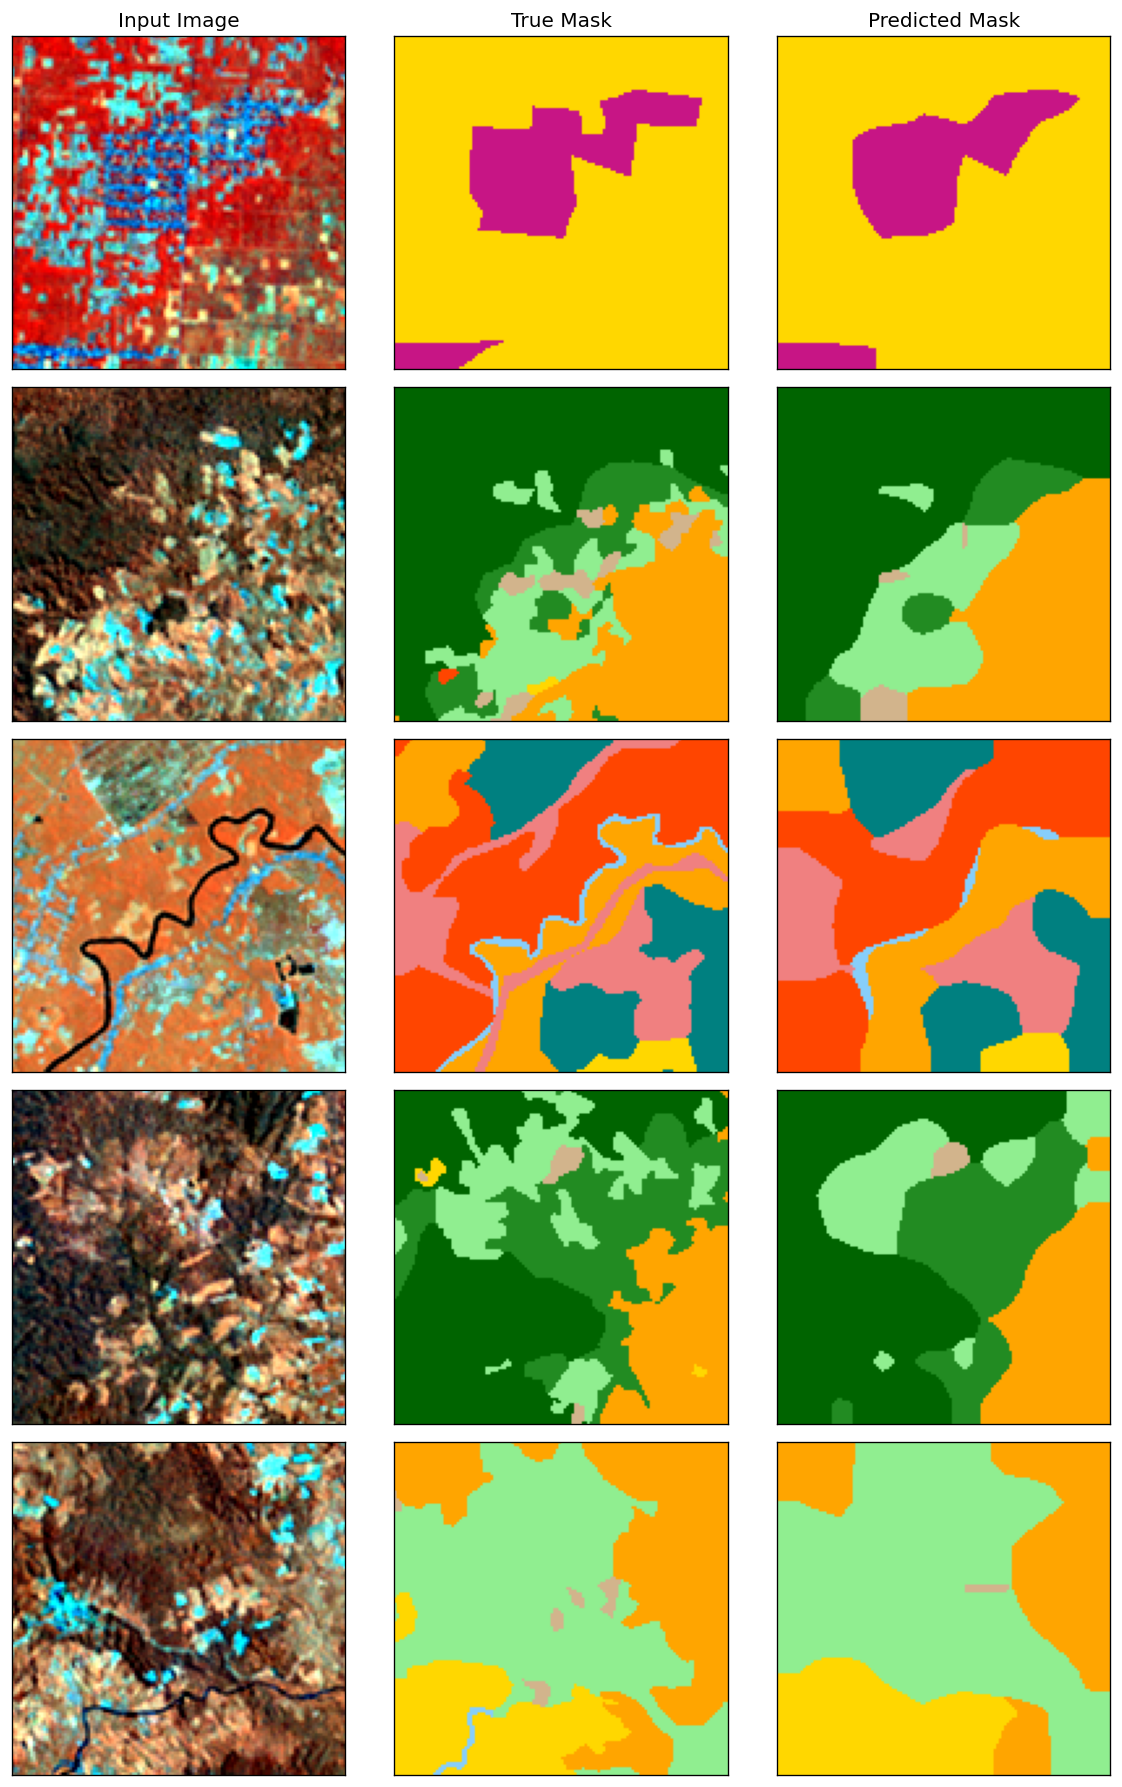

Saved: qualitative_examples.png


In [57]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---- helpers ---------------------------------------------------
def inv_normalize(x, mean, std):
    """x: [C,H,W] torch; mean/std: 1D arrays of length C"""
    mean_t = torch.as_tensor(mean, dtype=torch.float32, device=x.device).view(-1,1,1)
    std_t  = torch.as_tensor(std,  dtype=torch.float32, device=x.device).view(-1,1,1)
    return x * std_t + mean_t

def p_stretch(a, pmin=2, pmax=98):
    """percentile stretch to [0,1] for display"""
    a = np.asarray(a, np.float32)
    lo, hi = np.percentile(a, [pmin, pmax])
    if hi <= lo: return np.zeros_like(a, dtype=np.float32)
    return np.clip((a - lo) / (hi - lo), 0, 1).astype(np.float32)

# build a fast LUT for masks (0..K-1)
lut = np.zeros((num_classes, 3), np.uint8)
for i in range(num_classes):
    lut[i] = np.array(id2color_rgb[i], np.uint8)

def mask_to_rgb(mask_np):
    """mask_np: [H,W] int -> [H,W,3] uint8"""
    return lut[np.clip(mask_np, 0, num_classes-1)]

# choose 3 bands for the input composite (change if you want true RGB)
# NIR / SWIR1 / SWIR2 typically gives good contrast for land cover
comp_bands = (4, 5, 6)   # indices in your stacked image (0-based)

# ---- main viz function ----------------------------------------
@torch.no_grad()
def plot_qualitative_examples(dataset, n_rows=5, save_path="qualitative_examples.png"):
    n_rows = max(5, n_rows)  # at least 5
    idxs = np.random.choice(len(dataset), size=n_rows, replace=False)

    fig, axes = plt.subplots(n_rows, 3, figsize=(10, 3*n_rows), dpi=120)

    # column titles
    axes[0,0].set_title("Input Image")
    axes[0,1].set_title("True Mask")
    axes[0,2].set_title("Predicted Mask")

    for r, idx in enumerate(idxs):
        sample = dataset[idx]
        img_t  = sample["image"].to(device)          # [C,H,W], normalized
        y_np   = sample["mask"].cpu().numpy()        # [H,W], 0..K-1

        # predict
        x = img_t.unsqueeze(0)                       # [1,C,H,W]
        f = encoder(x, wvs)                          # [1,768,S,S]
        logits = decoder(f)                          # [1,K,H,W]
        pred_np = logits.argmax(1)[0].cpu().numpy()  # [H,W]

        # denormalize and make a 3-band composite for display
        img_denorm = inv_normalize(img_t, band_mean, band_std).cpu().numpy()  # [C,H,W]
        b1, b2, b3 = [p_stretch(img_denorm[i]) for i in comp_bands]
        comp = np.dstack([b1, b2, b3])  # [H,W,3], float in [0,1]

        # render row
        ax0, ax1, ax2 = axes[r]
        ax0.imshow(np.clip(comp, 0, 1))
        ax1.imshow(mask_to_rgb(y_np))
        ax2.imshow(mask_to_rgb(pred_np))

        for ax in (ax0, ax1, ax2):
            ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

# ---- call it on your test set ----
plot_qualitative_examples(test_ds, n_rows=5)  # increase n_rows if you want more